In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [6]:
from mlxtend.plotting import plot_decision_regions
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [9]:
np.random.seed(42)

X , y = make_circles(n_samples= 500, factor= 0.1 , noise= 0.35, random_state= 42)

X_train, X_test , y_train, y_test = train_test_split(X , y, random_state= 42, test_size=0.2)

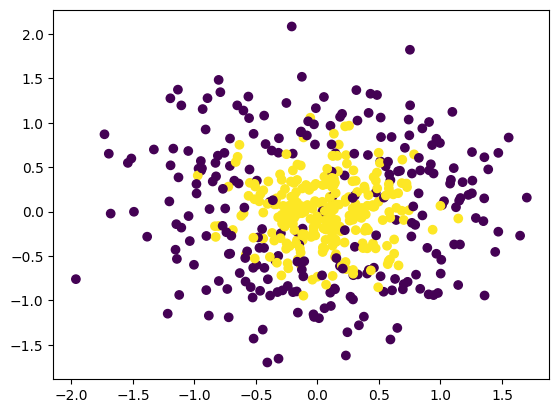

In [11]:
plt.scatter(X[:,0], X[:,1], c= y)

In [13]:
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

In [15]:
np.mean(cross_val_score(abc, X, y, scoring= 'accuracy', cv =10))

np.float64(0.812)

In [17]:
abc.fit(X_train, y_train)

AdaBoostClassifier()

In [20]:
y_pred = abc.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

print(f"Accuracy Score : {accuracy_score(y_test, y_pred)}")

Accuracy Score : 0.86


In [22]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()

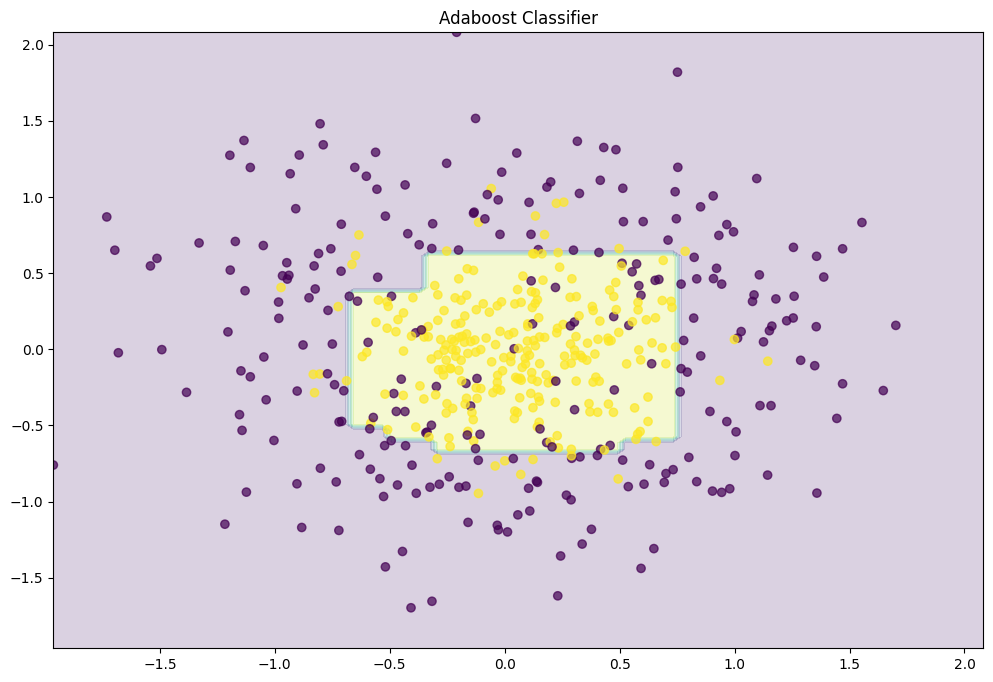

In [26]:
abc = AdaBoostClassifier(n_estimators=1000, learning_rate=0.1) # learning rate -> shrinkage parameter can reduce overfitting
abc.fit(X, y)
plot_decision_boundary(abc)